In [1]:
import pandas as pd
import os

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────

folder_path = "EDA Data Sources"

csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
xlsx_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.xlsx')]

print(f"Found {len(csv_files)} CSV files and {len(xlsx_files)} XLSX files\n")

dataframes = {}

# Load CSV files
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    df_name = file.replace('.csv', '')
    dataframes[df_name] = pd.read_csv(file_path)

# Load XLSX sheets
xlsx_path = os.path.join(folder_path, xlsx_files[0])

cpi_columns = ['Indent', 'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May',
               'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

cpi_averages_columns = ['Indent', 'Year', 'Semiannual_1', 'Semiannual_2',
                         'Annual_avg', 'Pct_change_1', 'Pct_change_2']

# First three rows are blank or contain descriptive information, so we skip them
dataframes['Index values'] = pd.read_excel(xlsx_path, sheet_name='Index values', skiprows=3)
dataframes['Index values'].columns = cpi_columns
# First three rows are blank or contain descriptive information, so we skip them
dataframes['Index averages'] = pd.read_excel(xlsx_path, sheet_name='Index averages', skiprows=3)
dataframes['Index averages'].columns = cpi_averages_columns


# ─────────────────────────────────────────────
# 2. CLEAN & FILTER DATA
# ─────────────────────────────────────────────

start_date = '2014-12-22'
end_date = '2024-12-20'

filtered_dataframes = {}

# Filter time series datasets by date range
date_columns = {
    'DFF': 'observation_date',
    'sp500_index': 'Date',
    'sp500_stocks': 'Date',
    'T10Y2Y': 'observation_date',
    'T10YIE': 'observation_date',
    'UNRATE': 'observation_date',
    'VIXCLS': 'observation_date',
}

# Override start date for UNRATE
start_date_override = {
    'UNRATE': '2014-11-01',
}

for name, date_col in date_columns.items():
    df = dataframes[name].copy()
    df[date_col] = pd.to_datetime(df[date_col])

# UNRATE has dates in MM/DD/YYYY format, so we specify the format for parsing
    if name == 'UNRATE':
        df[date_col] = pd.to_datetime(df[date_col], format='%m/%d/%Y')
    else:
        df[date_col] = pd.to_datetime(df[date_col])
    
    s_date = start_date_override.get(name, start_date)

    mask = (df[date_col] >= s_date) & (df[date_col] <= end_date)
    filtered_dataframes[name] = df[mask].reset_index(drop=True)
    print(f"{name}: {len(dataframes[name])} rows -> {len(filtered_dataframes[name])} rows")
    print(f"  Date range: {filtered_dataframes[name][date_col].min().date()} to {filtered_dataframes[name][date_col].max().date()}")

# Remove rows where Adj Close is null in sp500_stocks
filtered_dataframes['sp500_stocks'] = filtered_dataframes['sp500_stocks'][
    filtered_dataframes['sp500_stocks']['Adj Close'].notna()
].reset_index(drop=True)
print(f"\nsp500_stocks with null Adj Close removed: {filtered_dataframes['sp500_stocks'].shape}")

# Remove rows where VIXCLS is null
filtered_dataframes['VIXCLS'] = filtered_dataframes['VIXCLS'][
    filtered_dataframes['VIXCLS']['VIXCLS'].notna()
].reset_index(drop=True)
print(f"VIXCLS with null VIXCLS removed: {filtered_dataframes['VIXCLS'].shape}")

# Keep sp500_companies as-is (static reference table) no date filtering needed
filtered_dataframes['sp500_companies'] = dataframes['sp500_companies'].copy()
print(f"\nsp500_companies: kept as-is (static reference table)")

# Clean and filter CPI Index values
def clean_cpi(df, start_year=2014, end_year=2024):
    df = df.dropna(subset=['Year'])
    #must convert to numeric to filter by year range, coerce errors to NaN and drop those rows
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    df = df.dropna(subset=['Year'])
    df = df[df['Year'] < 2025]
    df['Year'] = df['Year'].astype(int)
    df = df[(df['Year'] >= start_year) & (df['Year'] <= end_year)].reset_index(drop=True)
    return df

cpi_values_filtered = clean_cpi(dataframes['Index values'])
cpi_values_filtered.loc[cpi_values_filtered['Year'] == 2014,
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov']] = None

cpi_averages_filtered = clean_cpi(dataframes['Index averages'])
cpi_averages_filtered = cpi_averages_filtered[['Indent', 'Year', 'Annual_avg']]

filtered_dataframes['Index values'] = cpi_values_filtered
filtered_dataframes['Index averages'] = cpi_averages_filtered


# ─────────────────────────────────────────────
# 3. DISPLAY SUMMARIES
# ─────────────────────────────────────────────

def display_summary(name, df):
    print("=" * 60)
    print(f"DATASET: {name}")
    print("=" * 60)
    print(f"\n Shape (rows, columns): {df.shape}")
    print(f"\n Column names:\n{df.columns.tolist()}")
    print(f"\n Data types:\n{df.dtypes}")
    print(f"\n First 5 rows:\n{df.head()}")
    print(f"\n Last 5 rows:\n{df.tail()}")
    print(f"\n Missing values per column:\n{df.isnull().sum()}")
    print(f"\n Percentage missing:\n{(df.isnull().sum() / len(df) * 100).round(2)}")
    print(f"\n Summary statistics:\n{df.describe()}")
    print(f"\n Duplicate rows: {df.duplicated().sum()}")
    print("\n")

for name, df in filtered_dataframes.items():
    display_summary(name, df)

Found 8 CSV files and 1 XLSX files

DFF: 26216 rows -> 3652 rows
  Date range: 2014-12-22 to 2024-12-20
sp500_index: 2517 rows -> 2517 rows
  Date range: 2014-12-22 to 2024-12-20
sp500_stocks: 1891536 rows -> 1263534 rows
  Date range: 2014-12-22 to 2024-12-20
T10Y2Y: 2950 rows -> 2610 rows
  Date range: 2014-12-22 to 2024-12-20
T10YIE: 6072 rows -> 2610 rows
  Date range: 2014-12-22 to 2024-12-20
UNRATE: 939 rows -> 122 rows
  Date range: 2014-11-01 to 2024-12-01
VIXCLS: 9463 rows -> 2610 rows
  Date range: 2014-12-22 to 2024-12-20

sp500_stocks with null Adj Close removed: (423337, 8)
VIXCLS with null VIXCLS removed: (2536, 2)

sp500_companies: kept as-is (static reference table)
DATASET: DFF

 Shape (rows, columns): (3652, 2)

 Column names:
['observation_date', 'DFF']

 Data types:
observation_date    datetime64[us]
DFF                        float64
dtype: object

 First 5 rows:
  observation_date   DFF
0       2014-12-22  0.13
1       2014-12-23  0.13
2       2014-12-24  0.13
3  

Stocks merged shape: (423337, 11)
Sectors represented: 11
Industries represented: 76
Null values:
Date         0
Symbol       0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Shortname    0
Sector       0
Industry     0
dtype: int64

Combined shape: (2517, 8)

Null values after merge:
Date      0
S&P500    0
VIXCLS    0
DFF       0
T10Y2Y    0
T10YIE    0
UNRATE    0
VWAC      0
dtype: int64

COMBINED DATASET SUMMARY

Shape: (2517, 8)

Column names:
['Date', 'S&P500', 'VIXCLS', 'DFF', 'T10Y2Y', 'T10YIE', 'UNRATE', 'VWAC']

Data types:
Date      datetime64[us]
S&P500           float64
VIXCLS           float64
DFF              float64
T10Y2Y           float64
T10YIE           float64
UNRATE           float64
VWAC             float64
dtype: object

First 5 rows:
        Date   S&P500  VIXCLS   DFF  T10Y2Y  T10YIE  UNRATE       VWAC
0 2014-12-22  2078.54   15.25  0.13    1.46    1.70     5.6  28.591985
1 2014-12-23  2082.17   14.80  0.13    1.53  

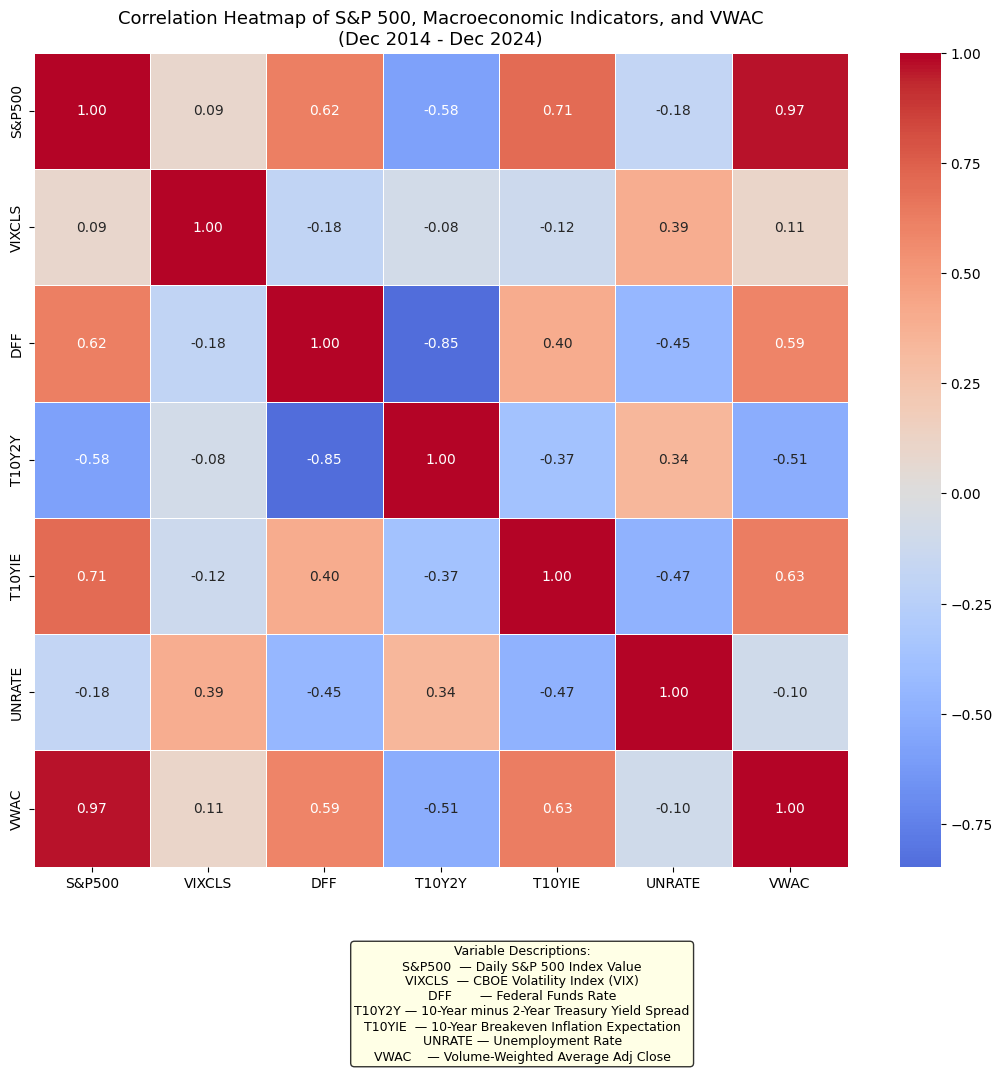

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────
# 4. BUILD COMBINED DATASET
# ─────────────────────────────────────────────

# ── Merge stocks with companies to get Sector and Industry ──
stocks_merged = filtered_dataframes['sp500_stocks'].merge(
    filtered_dataframes['sp500_companies'][['Symbol', 'Shortname', 'Sector', 'Industry']],
    on='Symbol',
    how='left'
)
stocks_merged['Date'] = pd.to_datetime(stocks_merged['Date'])

print(f"Stocks merged shape: {stocks_merged.shape}")
print(f"Sectors represented: {stocks_merged['Sector'].nunique()}")
print(f"Industries represented: {stocks_merged['Industry'].nunique()}")
print(f"Null values:\n{stocks_merged.isnull().sum()}\n")

# ── Calculate Volume-Weighted Average Adj Close (VWAC) ──
def weighted_avg(group):
    return (group['Adj Close'] * group['Volume']).sum() / group['Volume'].sum()

overall_wavg = stocks_merged.groupby('Date').apply(weighted_avg).reset_index()
overall_wavg.columns = ['Date', 'VWAC']

sector_wavg = stocks_merged.groupby(['Date', 'Sector']).apply(weighted_avg).reset_index()
sector_wavg.columns = ['Date', 'Sector', 'VWAC']

# ── Build unified daily combined dataframe ──
datasets_to_correlate = {
    'sp500_index': ('Date', 'S&P500'),
    'VIXCLS': ('observation_date', 'VIXCLS'),
    'DFF': ('observation_date', 'DFF'),
    'T10Y2Y': ('observation_date', 'T10Y2Y'),
    'T10YIE': ('observation_date', 'T10YIE'),
    'UNRATE': ('observation_date', 'UNRATE'),
}

# Use sp500_index as base calendar
combined = filtered_dataframes['sp500_index'].copy()
combined['Date'] = pd.to_datetime(combined['Date'])
combined = combined.sort_values('Date')

for name, (date_col, value_col) in datasets_to_correlate.items():
    if name == 'sp500_index':
        continue

    df = filtered_dataframes[name].copy()
    df = df.rename(columns={date_col: 'Date'})

    if name == 'UNRATE':
        # Use merge_asof to match nearest preceding UNRATE observation
        # This avoids NaN when UNRATE date (1st of month) doesn't exist in base calendar
        df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
        df = df.sort_values('Date')
        combined = pd.merge_asof(combined, df[['Date', value_col]],
                                 on='Date',
                                 direction='backward')
    else:
        df['Date'] = pd.to_datetime(df['Date'])
        combined = combined.merge(df[['Date', value_col]], on='Date', how='left')

# Forward fill remaining NaNs (VIXCLS weekends/holidays)
combined = combined.sort_values('Date').reset_index(drop=True)
combined = combined.ffill()

# Merge VWAC into combined
combined = combined.merge(overall_wavg[['Date', 'VWAC']], on='Date', how='left')

print(f"Combined shape: {combined.shape}")
print(f"\nNull values after merge:\n{combined.isnull().sum()}\n")

# ─────────────────────────────────────────────
# 5. COMBINED DATASET SUMMARY
# ─────────────────────────────────────────────

print("=" * 60)
print("COMBINED DATASET SUMMARY")
print("=" * 60)
print(f"\nShape: {combined.shape}")
print(f"\nColumn names:\n{combined.columns.tolist()}")
print(f"\nData types:\n{combined.dtypes}")
print(f"\nFirst 5 rows:\n{combined.head()}")
print(f"\nLast 5 rows:\n{combined.tail()}")
print(f"\nMissing values:\n{combined.isnull().sum()}")
print(f"\nPercentage missing:\n{(combined.isnull().sum() / len(combined) * 100).round(2)}")
print(f"\nSummary statistics:\n{combined.describe()}")

# ─────────────────────────────────────────────
# 6. CORRELATION HEATMAP WITH VWAC
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11, 9))

corr_matrix = combined.drop(columns='Date').corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title('Correlation Heatmap of S&P 500, Macroeconomic Indicators, and VWAC\n(Dec 2014 - Dec 2024)',
             fontsize=13)

legend_text = (
    "Variable Descriptions:\n"
    "S&P500  — Daily S&P 500 Index Value\n"
    "VIXCLS  — CBOE Volatility Index (VIX)\n"
    "DFF       — Federal Funds Rate\n"
    "T10Y2Y — 10-Year minus 2-Year Treasury Yield Spread\n"
    "T10YIE  — 10-Year Breakeven Inflation Expectation\n"
    "UNRATE — Unemployment Rate\n"
    "VWAC    — Volume-Weighted Average Adj Close"
)

fig.text(0.5, -0.05, legend_text,
         ha='center', va='top',
         fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

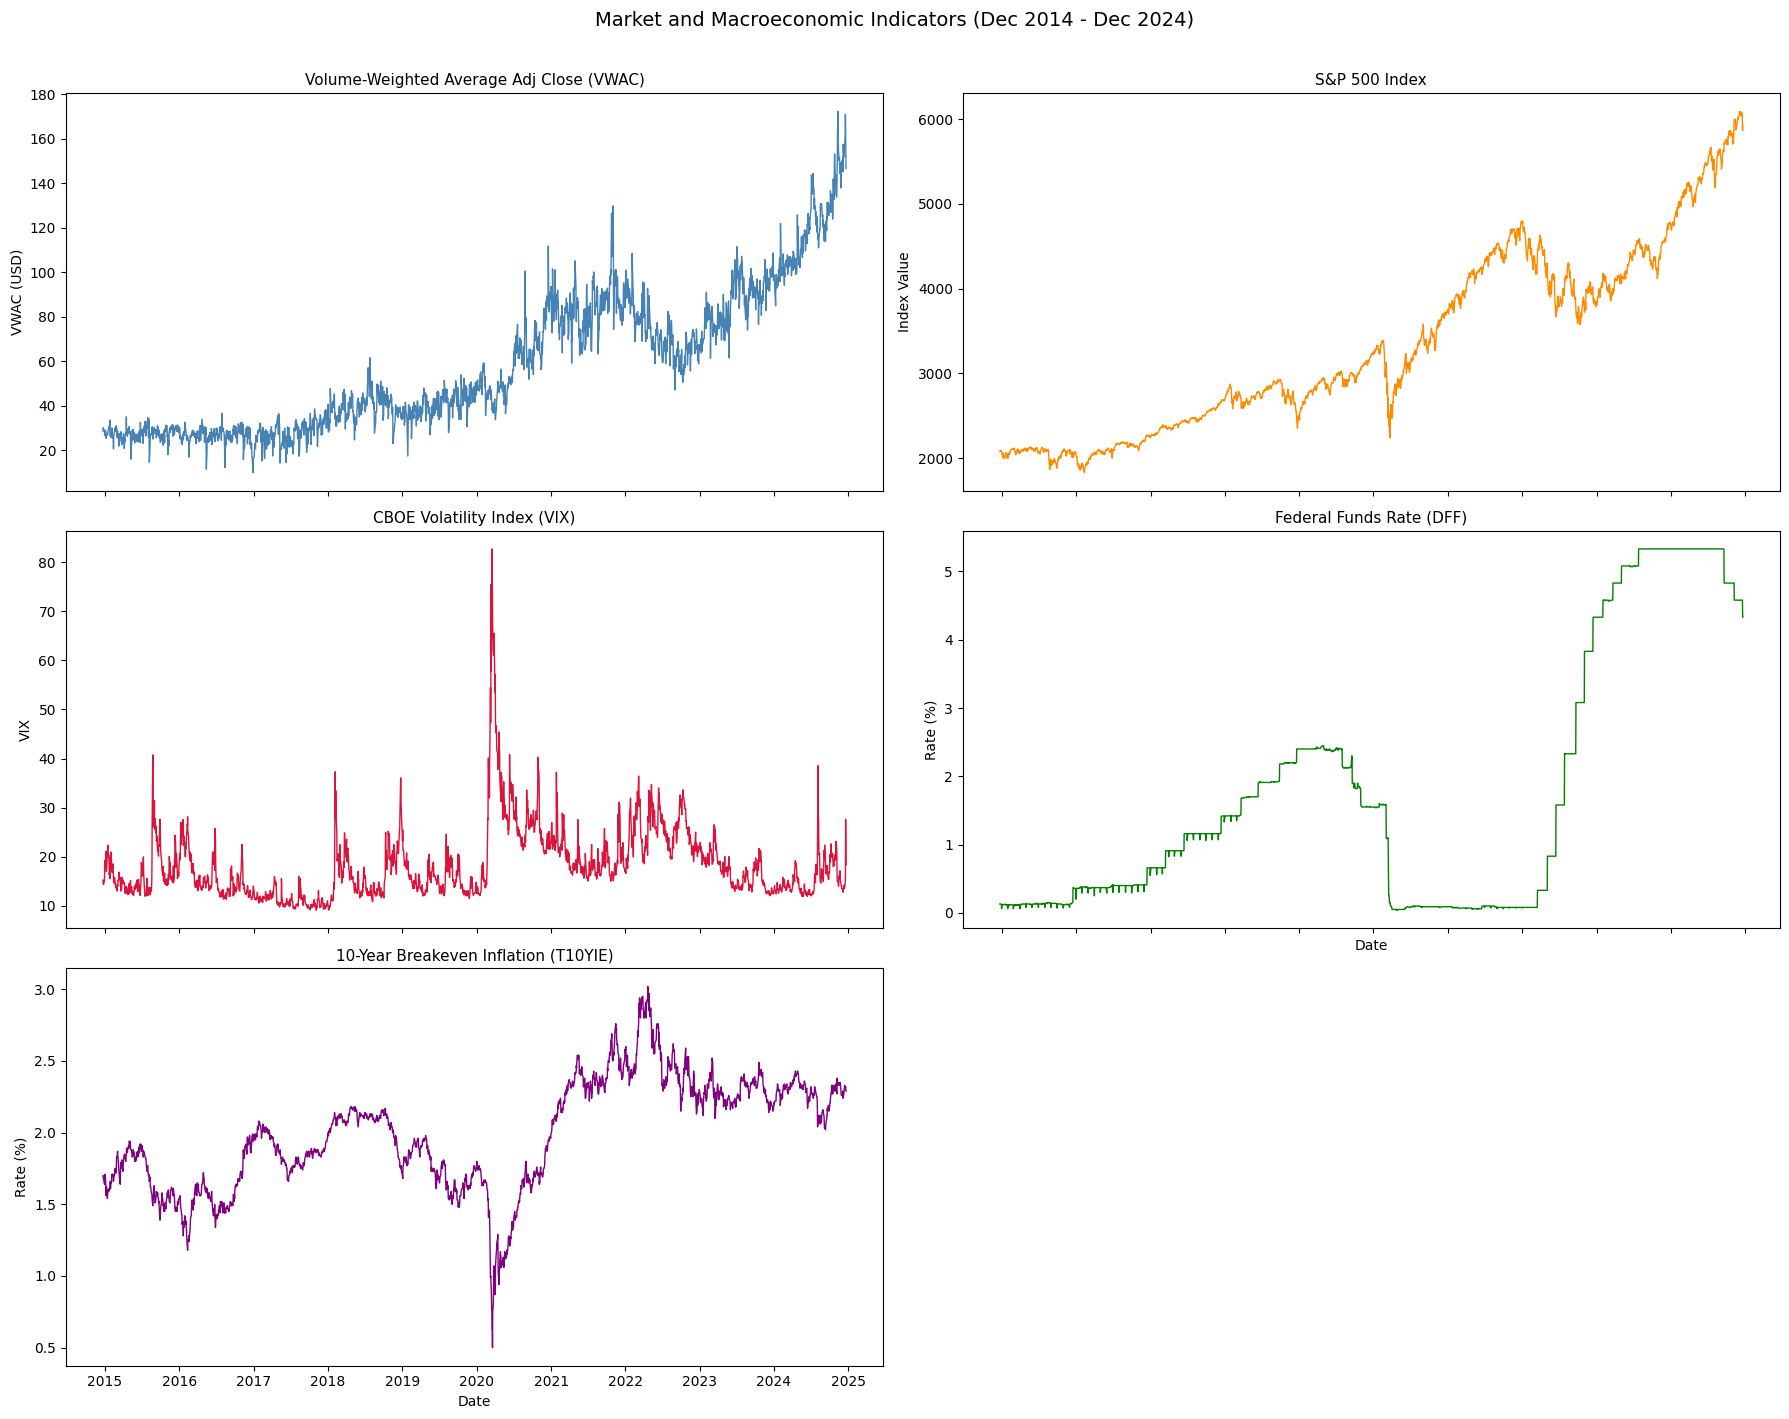

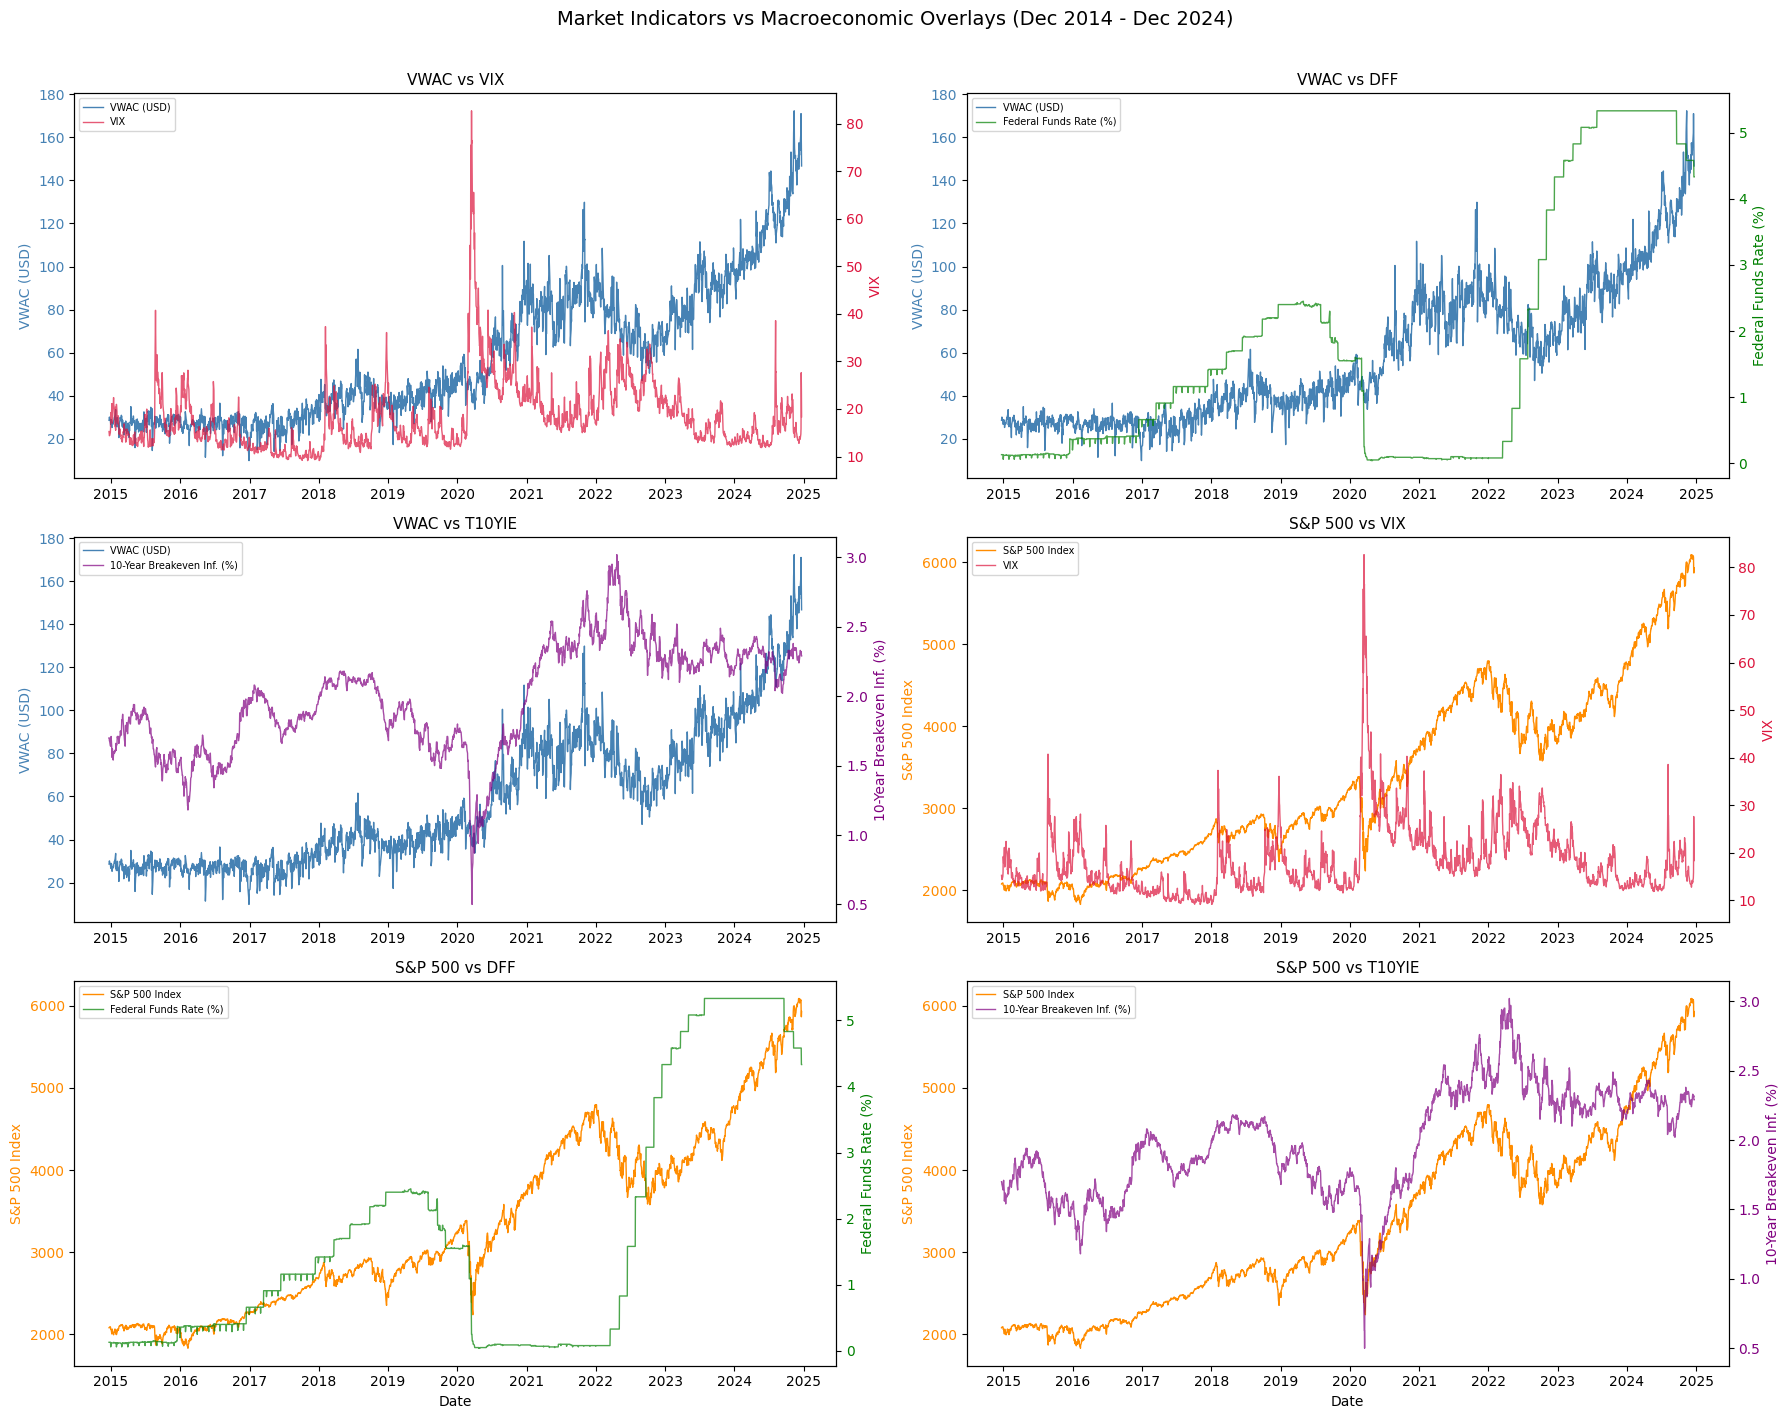

In [3]:
# ─────────────────────────────────────────────
# 7. LINE PLOTS
# ─────────────────────────────────────────────

# ── Individual line plots in a 3x2 grid (5 plots, last cell empty) ──
fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharex=True)
axes = axes.flatten()

plots = [
    ('VWAC',   'Volume-Weighted Average Adj Close (VWAC)', 'steelblue',  'VWAC (USD)'),
    ('S&P500', 'S&P 500 Index',                            'darkorange', 'Index Value'),
    ('VIXCLS', 'CBOE Volatility Index (VIX)',              'crimson',    'VIX'),
    ('DFF',    'Federal Funds Rate (DFF)',                 'green',      'Rate (%)'),
    ('T10YIE', '10-Year Breakeven Inflation (T10YIE)',     'purple',     'Rate (%)'),
]

for i, (col, title, color, ylabel) in enumerate(plots):
    axes[i].plot(combined['Date'], combined[col], color=color, linewidth=1)
    axes[i].set_title(title, fontsize=11)
    axes[i].set_ylabel(ylabel)
    if i >= 3:
        axes[i].set_xlabel('Date')

# Hide the empty 6th subplot
axes[5].set_visible(False)

plt.suptitle('Market and Macroeconomic Indicators (Dec 2014 - Dec 2024)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# ── Overlay plots in a 3x2 grid ──
# ─────────────────────────────────────────────

overlay_configs = [
    ('VWAC',   'VWAC (USD)',      'steelblue',  'VIXCLS', 'VIX',                        'crimson', 'VWAC vs VIX'),
    ('VWAC',   'VWAC (USD)',      'steelblue',  'DFF',    'Federal Funds Rate (%)',      'green',   'VWAC vs DFF'),
    ('VWAC',   'VWAC (USD)',      'steelblue',  'T10YIE', '10-Year Breakeven Inf. (%)', 'purple',  'VWAC vs T10YIE'),
    ('S&P500', 'S&P 500 Index',   'darkorange', 'VIXCLS', 'VIX',                        'crimson', 'S&P 500 vs VIX'),
    ('S&P500', 'S&P 500 Index',   'darkorange', 'DFF',    'Federal Funds Rate (%)',      'green',   'S&P 500 vs DFF'),
    ('S&P500', 'S&P 500 Index',   'darkorange', 'T10YIE', '10-Year Breakeven Inf. (%)', 'purple',  'S&P 500 vs T10YIE'),
]

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (base_col, base_label, base_color, macro_col, macro_label, macro_color, title) in enumerate(overlay_configs):
    ax1 = axes[i]
    ax1.plot(combined['Date'], combined[base_col],
             color=base_color, linewidth=1, label=base_label)
    ax1.set_ylabel(base_label, color=base_color)
    ax1.tick_params(axis='y', labelcolor=base_color)
    ax1.set_title(title, fontsize=11)

    ax2 = ax1.twinx()
    ax2.plot(combined['Date'], combined[macro_col],
             color=macro_color, linewidth=1, label=macro_label, alpha=0.7)
    ax2.set_ylabel(macro_label, color=macro_color)
    ax2.tick_params(axis='y', labelcolor=macro_color)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=7)

    if i >= 4:
        ax1.set_xlabel('Date')

plt.suptitle('Market Indicators vs Macroeconomic Overlays (Dec 2014 - Dec 2024)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Volatility distribution:
Volatility
0    1755
1     762
Name: count, dtype: int64

Low volatility (0) days: 1755
High volatility (1) days: 762
Percentage high volatility: 30.3%

First 5 rows with Volatility column:
        Date  VIXCLS  Volatility
0 2014-12-22   15.25           0
1 2014-12-23   14.80           0
2 2014-12-24   14.37           0
3 2014-12-26   14.50           0
4 2014-12-29   15.06           0

Low volatility dataset shape: (1755, 8)
High volatility dataset shape: (762, 8)


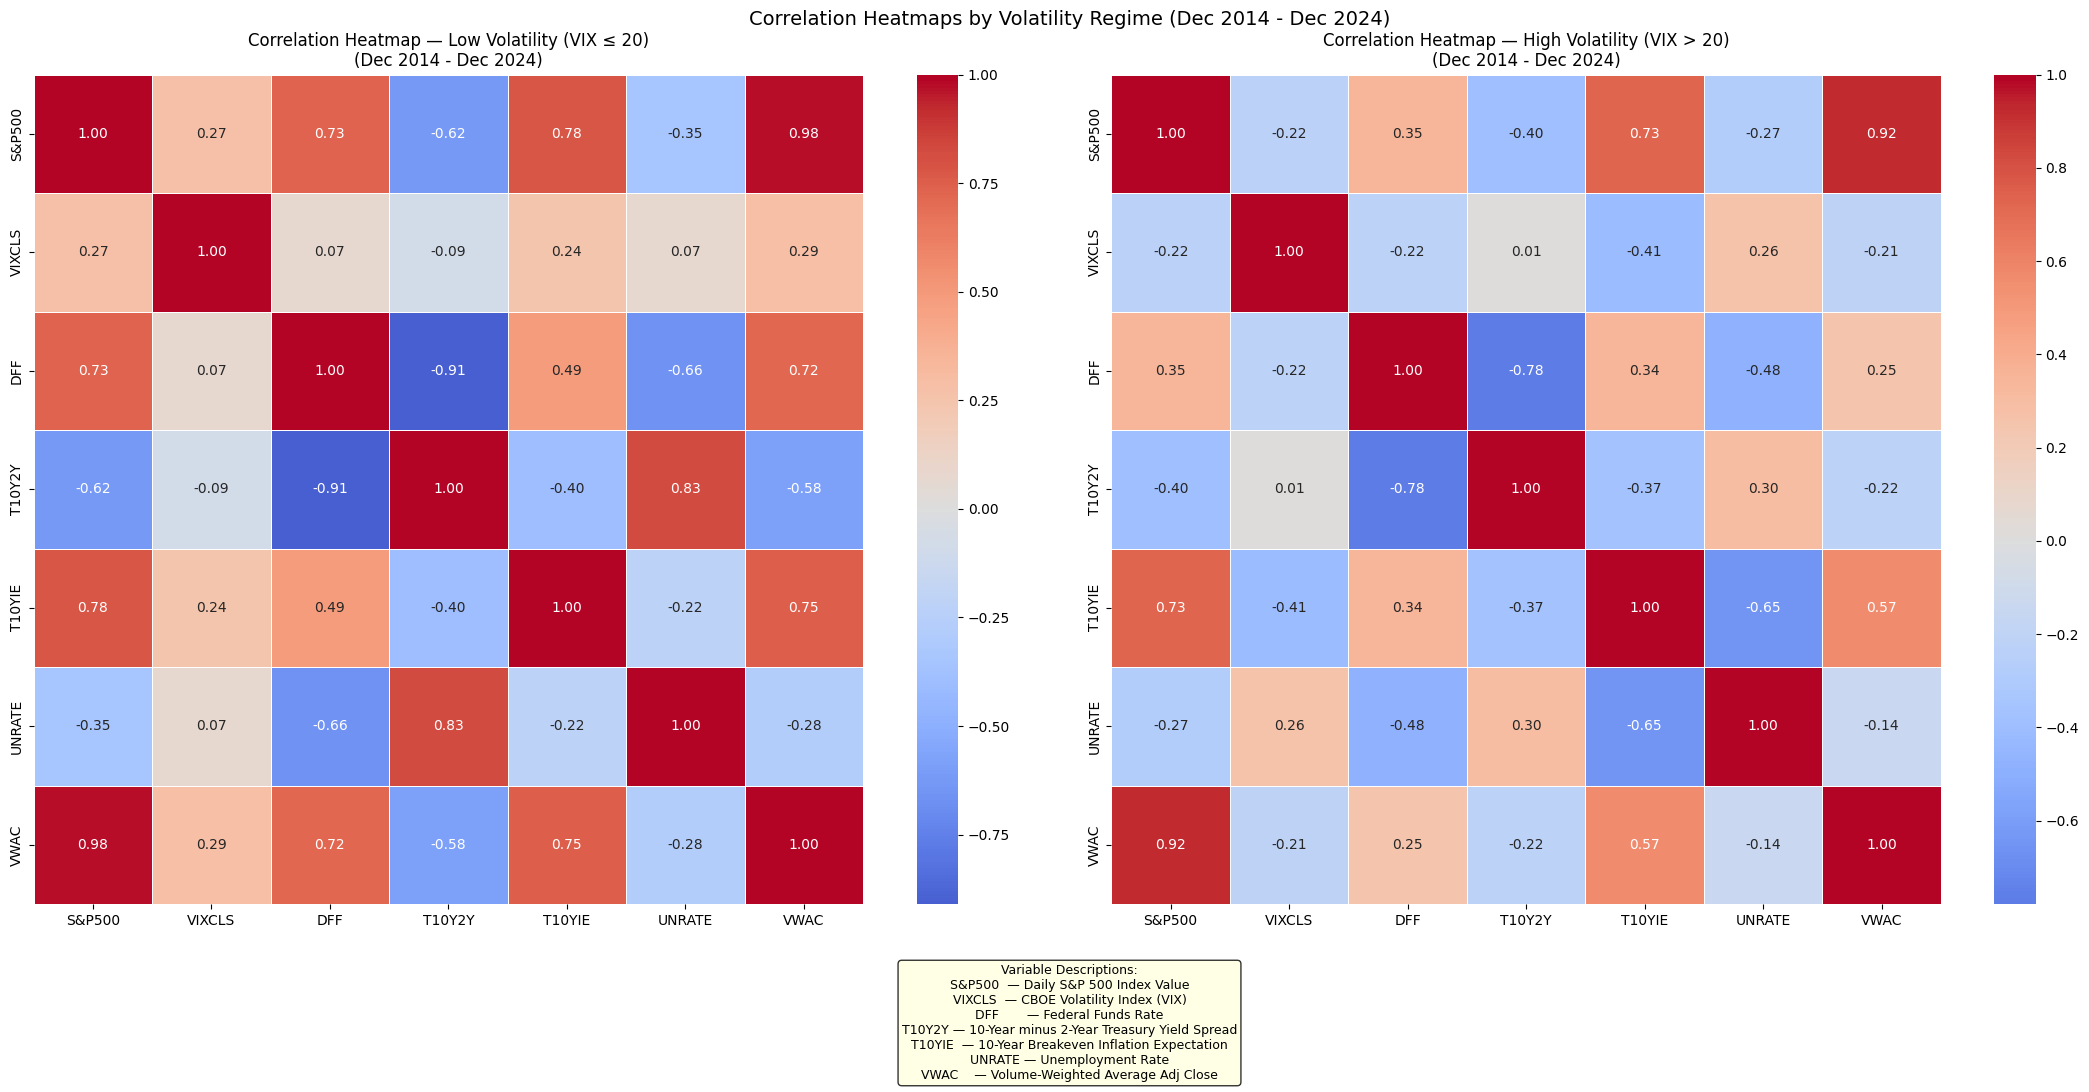

In [4]:
# ─────────────────────────────────────────────
# 8. VOLATILITY CLASSIFICATION
# ─────────────────────────────────────────────

# Add binary volatility column based on VIX threshold of 20
combined['Volatility'] = (combined['VIXCLS'] > 20).astype(int)

print(f"Volatility distribution:")
print(combined['Volatility'].value_counts())
print(f"\nLow volatility (0) days: {(combined['Volatility'] == 0).sum()}")
print(f"High volatility (1) days: {(combined['Volatility'] == 1).sum()}")
print(f"Percentage high volatility: {(combined['Volatility'] == 1).mean() * 100:.1f}%")
print(f"\nFirst 5 rows with Volatility column:\n{combined[['Date', 'VIXCLS', 'Volatility']].head()}")

# ─────────────────────────────────────────────
# 9. SPLIT CORRELATION HEATMAPS BY VOLATILITY
# ─────────────────────────────────────────────

# Split combined dataset by volatility regime
low_vol = combined[combined['Volatility'] == 0].drop(columns='Volatility')
high_vol = combined[combined['Volatility'] == 1].drop(columns='Volatility')

print(f"\nLow volatility dataset shape: {low_vol.shape}")
print(f"High volatility dataset shape: {high_vol.shape}")

legend_text = (
    "Variable Descriptions:\n"
    "S&P500  — Daily S&P 500 Index Value\n"
    "VIXCLS  — CBOE Volatility Index (VIX)\n"
    "DFF       — Federal Funds Rate\n"
    "T10Y2Y — 10-Year minus 2-Year Treasury Yield Spread\n"
    "T10YIE  — 10-Year Breakeven Inflation Expectation\n"
    "UNRATE — Unemployment Rate\n"
    "VWAC    — Volume-Weighted Average Adj Close"
)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# ── Low Volatility Heatmap (VIX <= 20) ──
corr_low = low_vol.drop(columns='Date').corr()
sns.heatmap(corr_low,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            ax=axes[0])
axes[0].set_title('Correlation Heatmap — Low Volatility (VIX ≤ 20)\n(Dec 2014 - Dec 2024)',
                  fontsize=12)

# ── High Volatility Heatmap (VIX > 20) ──
corr_high = high_vol.drop(columns='Date').corr()
sns.heatmap(corr_high,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            ax=axes[1])
axes[1].set_title('Correlation Heatmap — High Volatility (VIX > 20)\n(Dec 2014 - Dec 2024)',
                  fontsize=12)

fig.text(0.5, -0.05, legend_text,
         ha='center', va='top',
         fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Correlation Heatmaps by Volatility Regime (Dec 2014 - Dec 2024)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

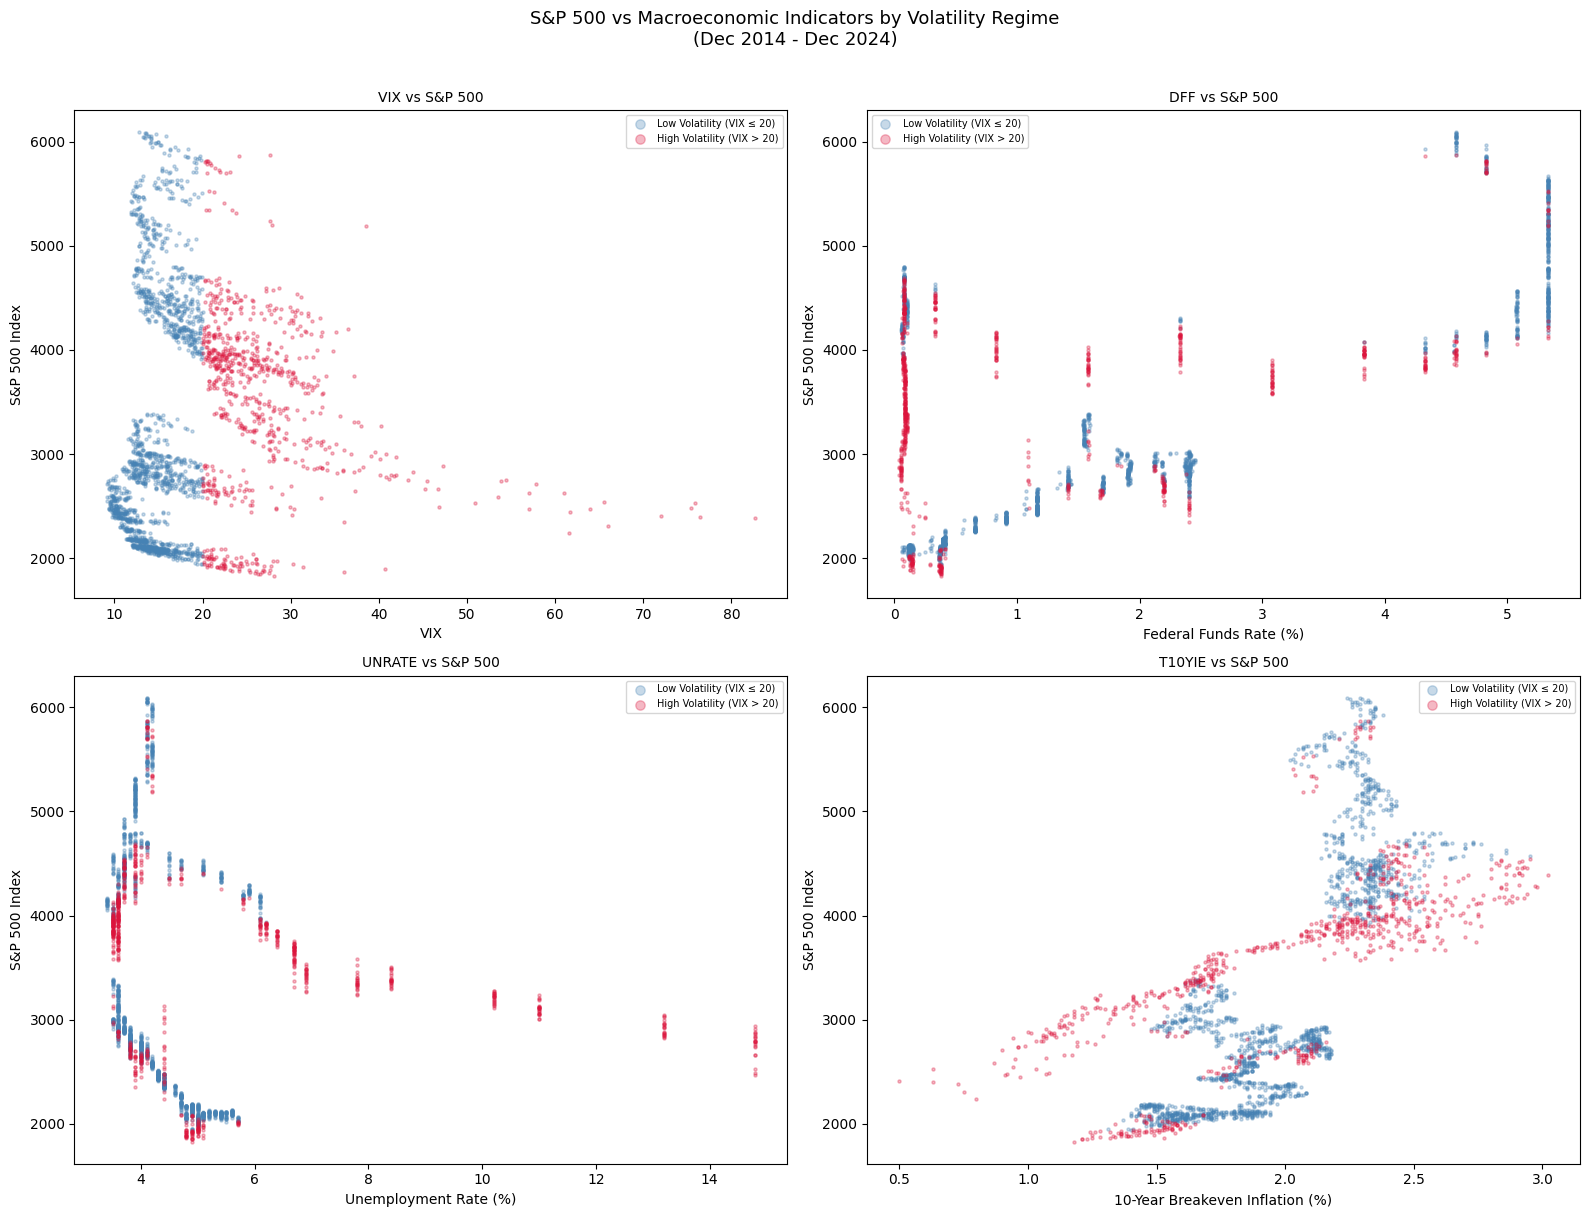

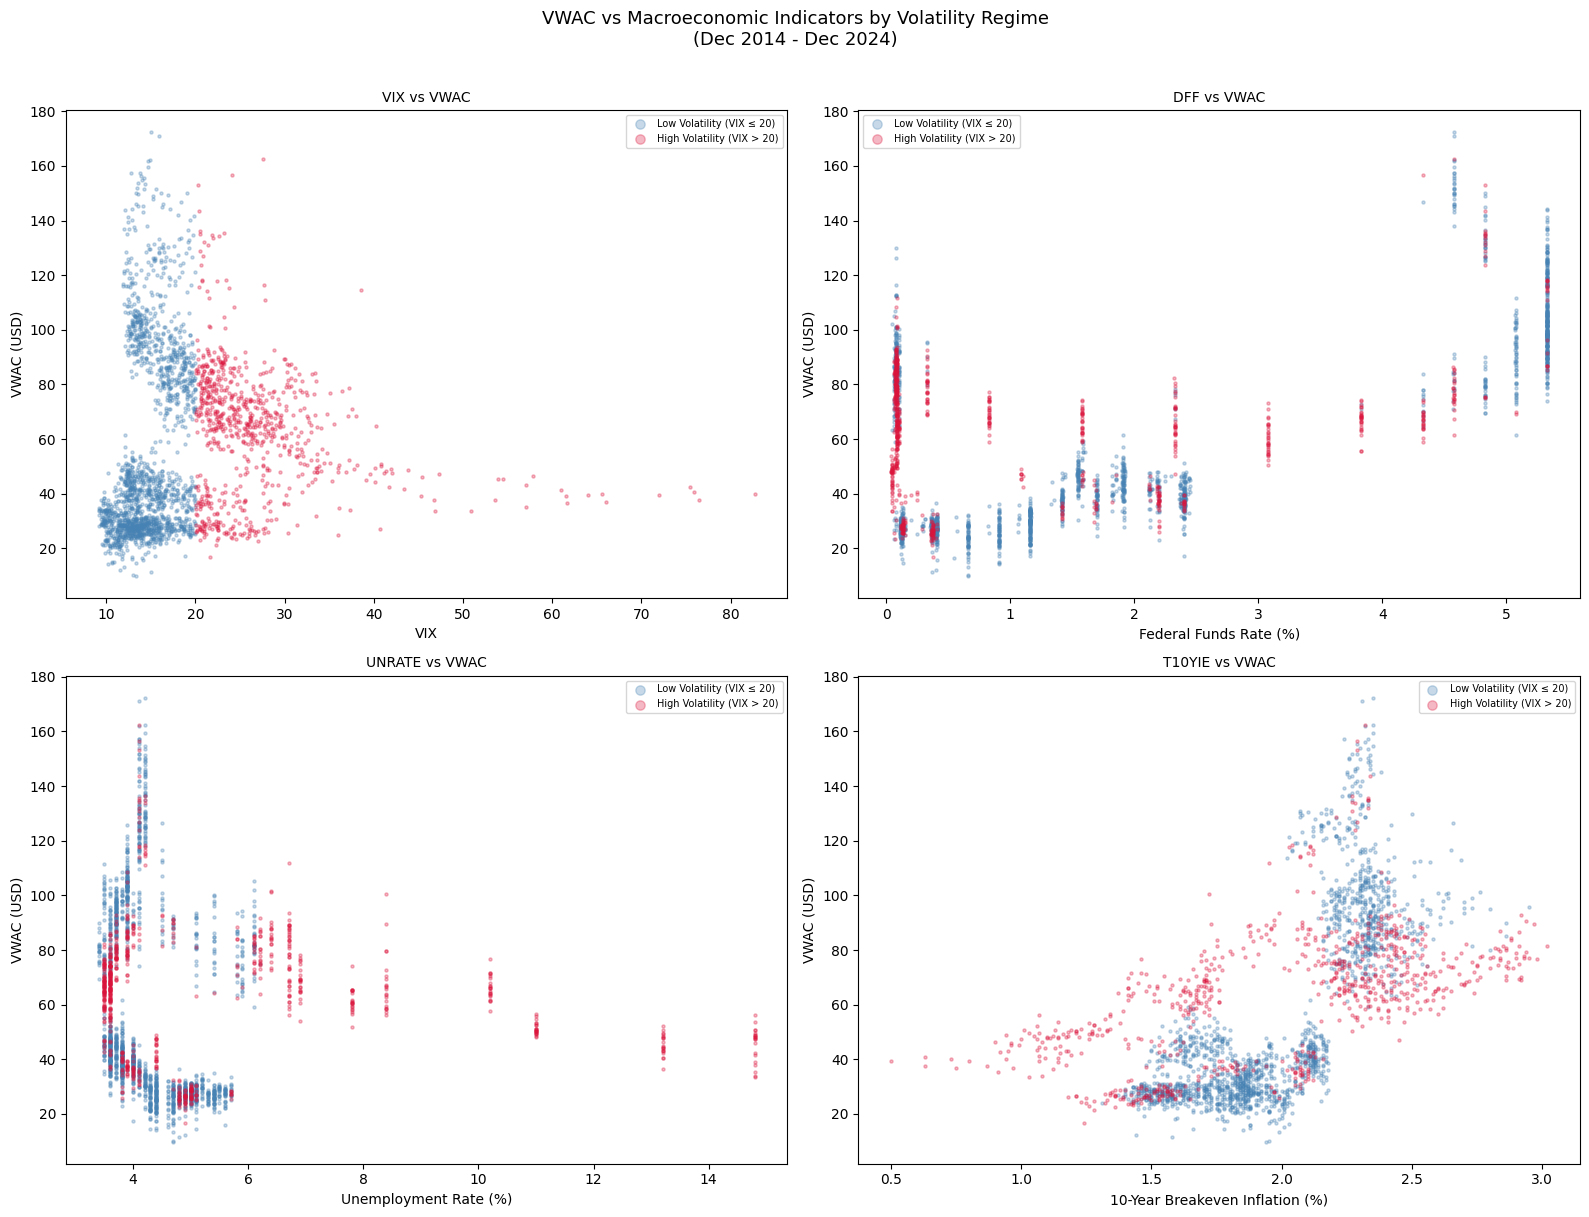

In [5]:
# ─────────────────────────────────────────────
# 10. SCATTER PLOTS BY VOLATILITY REGIME
# ─────────────────────────────────────────────

# Color map for volatility regime
colors = {0: 'steelblue', 1: 'crimson'}
labels = {0: 'Low Volatility (VIX ≤ 20)', 1: 'High Volatility (VIX > 20)'}

def scatter_by_regime(ax, x_col, y_col, xlabel, ylabel, title):
    for regime in [0, 1]:
        subset = combined[combined['Volatility'] == regime]
        ax.scatter(subset[x_col], subset[y_col],
                   c=colors[regime],
                   label=labels[regime],
                   alpha=0.3,
                   s=5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7, markerscale=3)

# ── S&P500 Scatter Plots ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

scatter_by_regime(axes[0], 'VIXCLS', 'S&P500',
                  'VIX', 'S&P 500 Index',
                  'VIX vs S&P 500')

scatter_by_regime(axes[1], 'DFF', 'S&P500',
                  'Federal Funds Rate (%)', 'S&P 500 Index',
                  'DFF vs S&P 500')

scatter_by_regime(axes[2], 'UNRATE', 'S&P500',
                  'Unemployment Rate (%)', 'S&P 500 Index',
                  'UNRATE vs S&P 500')

scatter_by_regime(axes[3], 'T10YIE', 'S&P500',
                  '10-Year Breakeven Inflation (%)', 'S&P 500 Index',
                  'T10YIE vs S&P 500')

plt.suptitle('S&P 500 vs Macroeconomic Indicators by Volatility Regime\n(Dec 2014 - Dec 2024)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── VWAC Scatter Plots ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

scatter_by_regime(axes[0], 'VIXCLS', 'VWAC',
                  'VIX', 'VWAC (USD)',
                  'VIX vs VWAC')

scatter_by_regime(axes[1], 'DFF', 'VWAC',
                  'Federal Funds Rate (%)', 'VWAC (USD)',
                  'DFF vs VWAC')

scatter_by_regime(axes[2], 'UNRATE', 'VWAC',
                  'Unemployment Rate (%)', 'VWAC (USD)',
                  'UNRATE vs VWAC')

scatter_by_regime(axes[3], 'T10YIE', 'VWAC',
                  '10-Year Breakeven Inflation (%)', 'VWAC (USD)',
                  'T10YIE vs VWAC')

plt.suptitle('VWAC vs Macroeconomic Indicators by Volatility Regime\n(Dec 2014 - Dec 2024)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [6]:
# ── SMA50 and SMA200 per stock ──
stocks_merged = stocks_merged.sort_values(['Symbol', 'Date'])

stocks_merged['SMA50'] = stocks_merged.groupby('Symbol')['Close'].transform(
    lambda x: x.rolling(window=50).mean()
)

stocks_merged['SMA200'] = stocks_merged.groupby('Symbol')['Close'].transform(
    lambda x: x.rolling(window=200).mean()
)

# ── Aggregate to daily market-wide value using volume-weighted average ──
def vw_average(df, col):
    return df.groupby('Date').apply(
        lambda g: (g[col] * g['Volume']).sum() / g['Volume'].sum()
    ).reset_index().rename(columns={0: col})

sma50_daily = vw_average(stocks_merged.dropna(subset=['SMA50']), 'SMA50')
sma200_daily = vw_average(stocks_merged.dropna(subset=['SMA200']), 'SMA200')

print(f"SMA50 daily shape: {sma50_daily.shape}")
print(f"SMA200 daily shape: {sma200_daily.shape}")
print(f"\nSMA50 head:\n{sma50_daily.head()}")
print(f"\nSMA200 head:\n{sma200_daily.head()}")
print(f"\nSMA50 null count: {sma50_daily['SMA50'].isnull().sum()}")
print(f"\nSMA200 null count: {sma200_daily['SMA200'].isnull().sum()}")

SMA50 daily shape: (2468, 2)
SMA200 daily shape: (2318, 2)

SMA50 head:
        Date      SMA50
0 2015-03-05  30.260547
1 2015-03-06  33.128310
2 2015-03-09  32.618610
3 2015-03-10  26.773389
4 2015-03-11  32.827744

SMA200 head:
        Date     SMA200
0 2015-10-07  31.989113
1 2015-10-08  29.112757
2 2015-10-09  28.691982
3 2015-10-12  31.700334
4 2015-10-13  30.657814

SMA50 null count: 0

SMA200 null count: 0


In [7]:
# ── RSI per stock ──
def calculate_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

stocks_merged['RSI'] = stocks_merged.groupby('Symbol')['Close'].transform(
    lambda x: calculate_rsi(x)
)

# ── Aggregate to daily market-wide value using volume-weighted average ──
rsi_daily = vw_average(stocks_merged.dropna(subset=['RSI']), 'RSI')

print(f"RSI daily shape: {rsi_daily.shape}")
print(f"\nRSI head:\n{rsi_daily.head()}")
print(f"\nRSI null count: {rsi_daily['RSI'].isnull().sum()}")
print(f"\nRSI min: {rsi_daily['RSI'].min():.2f}")
print(f"RSI max: {rsi_daily['RSI'].max():.2f}")
print(f"RSI mean: {rsi_daily['RSI'].mean():.2f}")

RSI daily shape: (2503, 2)

RSI head:
        Date        RSI
0 2015-01-13  38.113158
1 2015-01-14  33.726202
2 2015-01-15  32.482084
3 2015-01-16  36.617689
4 2015-01-20  36.815768

RSI null count: 0

RSI min: 16.07
RSI max: 82.05
RSI mean: 54.16


In [8]:
# ── MACD per stock ──
def calculate_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return histogram

stocks_merged['MACD'] = stocks_merged.groupby('Symbol')['Close'].transform(
    lambda x: calculate_macd(x)
)

# ── Aggregate to daily market-wide value using volume-weighted average ──
macd_daily = vw_average(stocks_merged.dropna(subset=['MACD']), 'MACD')

print(f"MACD daily shape: {macd_daily.shape}")
print(f"\nMACd head:\n{macd_daily.head()}")
print(f"\nMACD null count: {macd_daily['MACD'].isnull().sum()}")
print(f"\nMACD min: {macd_daily['MACD'].min():.2f}")
print(f"MACD max: {macd_daily['MACD'].max():.2f}")
print(f"MACD mean: {macd_daily['MACD'].mean():.2f}")

MACD daily shape: (2517, 2)

MACd head:
        Date      MACD
0 2014-12-22  0.000000
1 2014-12-23  0.002167
2 2014-12-24  0.011485
3 2014-12-26  0.025438
4 2014-12-29  0.029721

MACD null count: 0

MACD min: -1.54
MACD max: 2.15
MACD mean: 0.02


In [9]:
# ── Bollinger Bandwidth per stock ──
def calculate_bollinger_bandwidth(series, window=20):
    middle_band = series.rolling(window=window).mean()
    std = series.rolling(window=window).std()
    upper_band = middle_band + (2 * std)
    lower_band = middle_band - (2 * std)
    bandwidth = (upper_band - lower_band) / middle_band
    return bandwidth

stocks_merged['BB_Bandwidth'] = stocks_merged.groupby('Symbol')['Close'].transform(
    lambda x: calculate_bollinger_bandwidth(x)
)

# ── Aggregate to daily market-wide value using volume-weighted average ──
bb_daily = vw_average(stocks_merged.dropna(subset=['BB_Bandwidth']), 'BB_Bandwidth')

print(f"Bollinger Bandwidth daily shape: {bb_daily.shape}")
print(f"\nBollinger Bandwidth head:\n{bb_daily.head()}")
print(f"\nBollinger Bandwidth null count: {bb_daily['BB_Bandwidth'].isnull().sum()}")
print(f"\nBollinger Bandwidth min: {bb_daily['BB_Bandwidth'].min():.4f}")
print(f"Bollinger Bandwidth max: {bb_daily['BB_Bandwidth'].max():.4f}")
print(f"Bollinger Bandwidth mean: {bb_daily['BB_Bandwidth'].mean():.4f}")

Bollinger Bandwidth daily shape: (2498, 2)

Bollinger Bandwidth head:
        Date  BB_Bandwidth
0 2015-01-21      0.119911
1 2015-01-22      0.121130
2 2015-01-23      0.125522
3 2015-01-26      0.123294
4 2015-01-27      0.117382

Bollinger Bandwidth null count: 0

Bollinger Bandwidth min: 0.0704
Bollinger Bandwidth max: 0.6012
Bollinger Bandwidth mean: 0.1694


In [10]:
# ── ATR per stock ──
def calculate_atr(group, window=14):
    high = group['High']
    low = group['Low']
    prev_close = group['Close'].shift(1)
    
    true_range = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    
    atr = true_range.rolling(window=window).mean()
    return atr

stocks_merged['ATR'] = stocks_merged.groupby('Symbol').apply(
    lambda g: calculate_atr(g)
).reset_index(level=0, drop=True)

# ── Aggregate to daily market-wide value using volume-weighted average ──
atr_daily = vw_average(stocks_merged.dropna(subset=['ATR']), 'ATR')

print(f"ATR daily shape: {atr_daily.shape}")
print(f"\nATR head:\n{atr_daily.head()}")
print(f"\nATR null count: {atr_daily['ATR'].isnull().sum()}")
print(f"\nATR min: {atr_daily['ATR'].min():.4f}")
print(f"ATR max: {atr_daily['ATR'].max():.4f}")
print(f"ATR mean: {atr_daily['ATR'].mean():.4f}")

ATR daily shape: (2504, 2)

ATR head:
        Date       ATR
0 2015-01-12  0.650493
1 2015-01-13  0.697260
2 2015-01-14  0.765129
3 2015-01-15  0.809409
4 2015-01-16  0.826955

ATR null count: 0

ATR min: 0.2381
ATR max: 6.3355
ATR mean: 1.8993


In [11]:
# ── OBV per stock ──
def calculate_obv(group):
    close = group['Close']
    volume = group['Volume']
    
    direction = close.diff().apply(
        lambda x: 1 if x > 0 else (-1 if x < 0 else 0)
    )
    obv = (direction * volume).cumsum()
    return obv

stocks_merged['OBV'] = stocks_merged.groupby('Symbol').apply(
    lambda g: calculate_obv(g)
).reset_index(level=0, drop=True)

# ── Aggregate using simple average across stocks per day ──
# Simple average used instead of volume weighting to avoid double counting volume
obv_daily = stocks_merged.dropna(subset=['OBV']).groupby('Date')['OBV'].mean().reset_index()
obv_daily.columns = ['Date', 'OBV']

print(f"OBV daily shape: {obv_daily.shape}")
print(f"\nOBV head:\n{obv_daily.head()}")
print(f"\nOBV null count: {obv_daily['OBV'].isnull().sum()}")
print(f"\nOBV min: {obv_daily['OBV'].min():.0f}")
print(f"OBV max: {obv_daily['OBV'].max():.0f}")
print(f"OBV mean: {obv_daily['OBV'].mean():.0f}")

OBV daily shape: (2517, 2)

OBV head:
        Date           OBV
0 2014-12-22  0.000000e+00
1 2014-12-23  2.785381e+05
2 2014-12-24  7.676117e+03
3 2014-12-26  1.908951e+06
4 2014-12-29  1.210256e+06

OBV null count: 0

OBV min: -25260688
OBV max: 1096510911
OBV mean: 567698246


In [12]:
# ─────────────────────────────────────────────
# 11. MERGE TECHNICAL INDICATORS INTO COMBINED
# ─────────────────────────────────────────────

# List of all technical indicator daily dataframes
technical_indicators = {
    'SMA50': sma50_daily,
    'SMA200': sma200_daily,
    'RSI': rsi_daily,
    'MACD': macd_daily,
    'BB_Bandwidth': bb_daily,
    'ATR': atr_daily,
    'OBV': obv_daily,
}

# Merge each technical indicator into combined
combined_tech = combined.copy()

for indicator, df in technical_indicators.items():
    df['Date'] = pd.to_datetime(df['Date'])
    combined_tech = combined_tech.merge(df, on='Date', how='left')
    print(f"After merging {indicator}: {combined_tech.shape} | "
          f"Nulls: {combined_tech[indicator].isnull().sum()}")

print(f"\nFinal combined_tech shape: {combined_tech.shape}")
print(f"\nColumn names:\n{combined_tech.columns.tolist()}")
print(f"\nNull values:\n{combined_tech.isnull().sum()}")
print(f"\nFirst 5 rows:\n{combined_tech.head()}")
print(f"\nLast 5 rows:\n{combined_tech.tail()}")
print(f"\nSummary statistics:\n{combined_tech.describe()}")

After merging SMA50: (2517, 10) | Nulls: 49
After merging SMA200: (2517, 11) | Nulls: 199
After merging RSI: (2517, 12) | Nulls: 14
After merging MACD: (2517, 13) | Nulls: 0
After merging BB_Bandwidth: (2517, 14) | Nulls: 19
After merging ATR: (2517, 15) | Nulls: 13
After merging OBV: (2517, 16) | Nulls: 0

Final combined_tech shape: (2517, 16)

Column names:
['Date', 'S&P500', 'VIXCLS', 'DFF', 'T10Y2Y', 'T10YIE', 'UNRATE', 'VWAC', 'Volatility', 'SMA50', 'SMA200', 'RSI', 'MACD', 'BB_Bandwidth', 'ATR', 'OBV']

Null values:
Date              0
S&P500            0
VIXCLS            0
DFF               0
T10Y2Y            0
T10YIE            0
UNRATE            0
VWAC              0
Volatility        0
SMA50            49
SMA200          199
RSI              14
MACD              0
BB_Bandwidth     19
ATR              13
OBV               0
dtype: int64

First 5 rows:
        Date   S&P500  VIXCLS   DFF  T10Y2Y  T10YIE  UNRATE       VWAC  \
0 2014-12-22  2078.54   15.25  0.13    1.46    1.7

combined_tech_clean shape after dropping nulls: (2318, 16)
Date range: 2015-10-07 to 2024-12-20

Low volatility rows: 1593
High volatility rows: 725


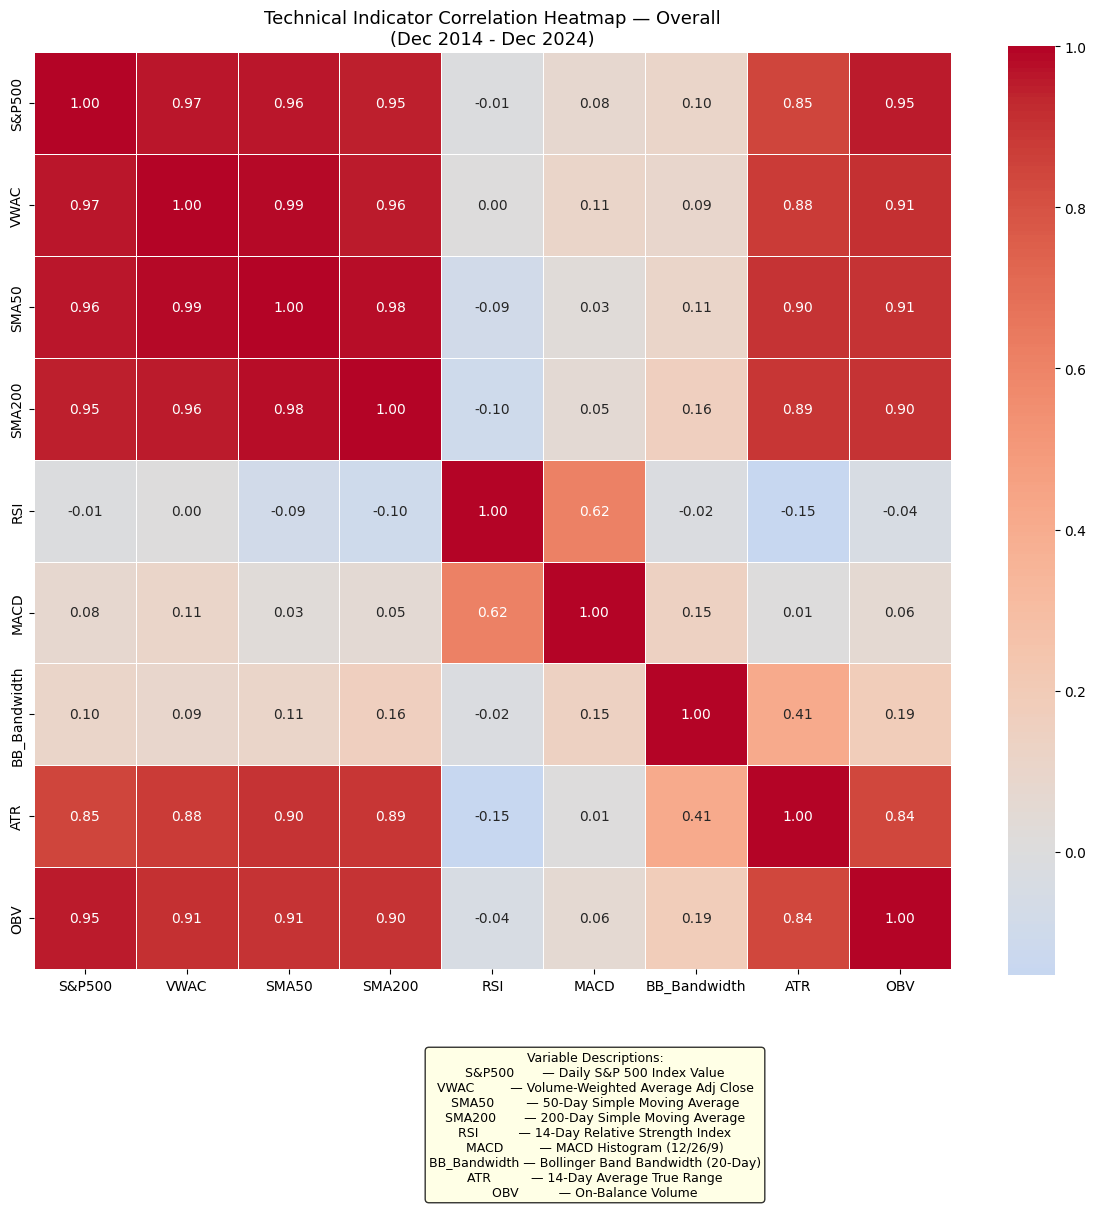

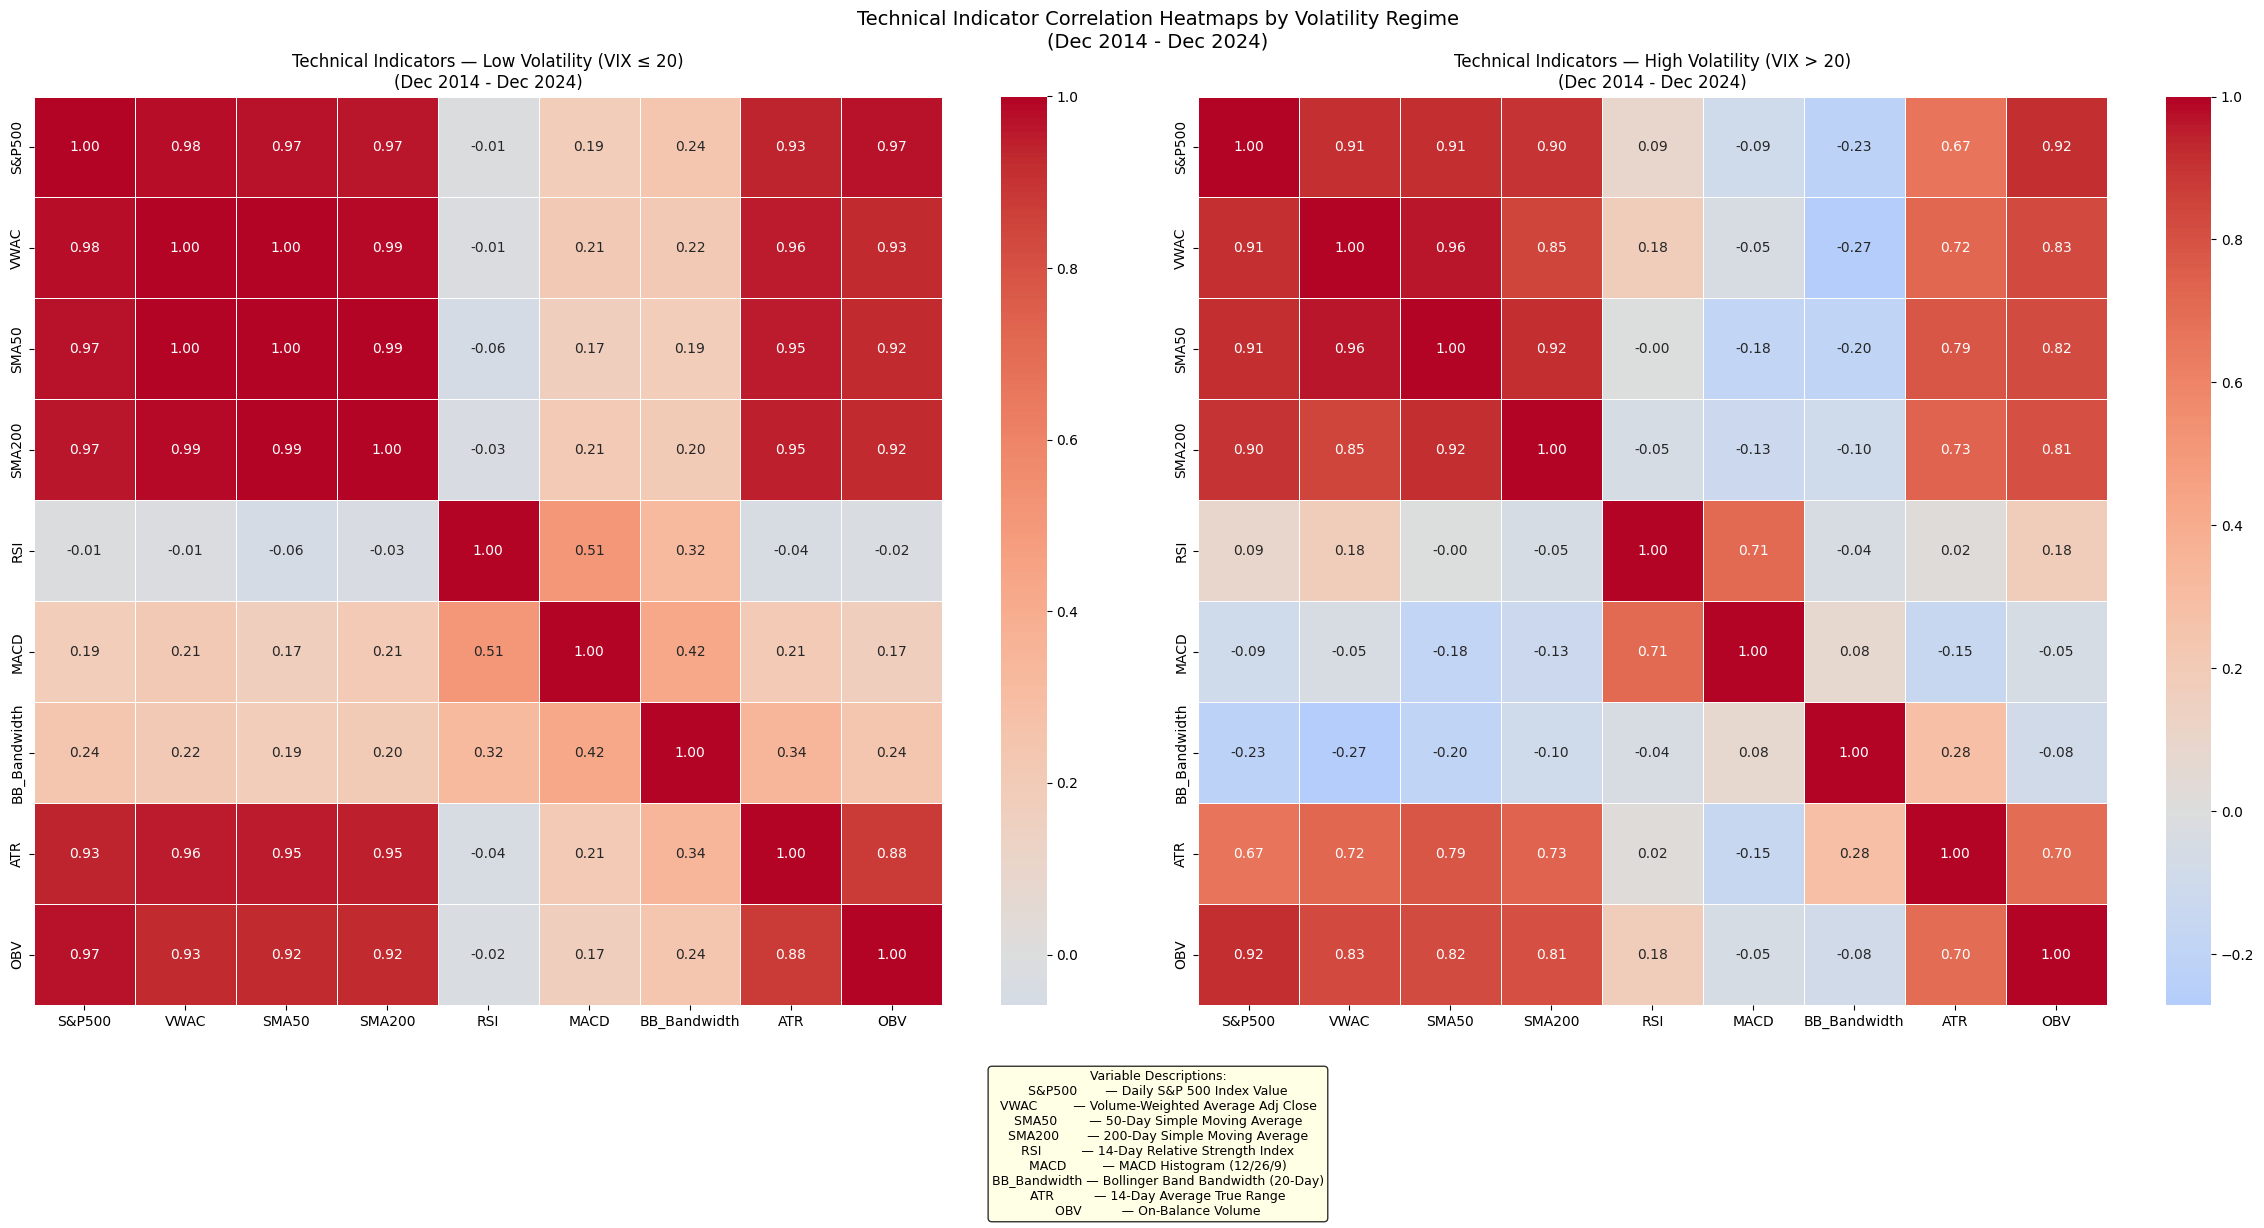

In [13]:
# ─────────────────────────────────────────────
# 12. TECHNICAL INDICATOR CORRELATION HEATMAPS
# ─────────────────────────────────────────────

# Drop nulls for clean correlation calculation
combined_tech_clean = combined_tech.dropna().reset_index(drop=True)

print(f"combined_tech_clean shape after dropping nulls: {combined_tech_clean.shape}")
print(f"Date range: {combined_tech_clean['Date'].min().date()} to {combined_tech_clean['Date'].max().date()}")

# Columns to include in technical heatmap
# Exclude Volatility as it is derived from VIXCLS
tech_cols = ['S&P500', 'VWAC', 'SMA50', 'SMA200', 'RSI', 'MACD', 'BB_Bandwidth', 'ATR', 'OBV']

# Split by volatility regime
low_vol_tech = combined_tech_clean[combined_tech_clean['Volatility'] == 0][tech_cols]
high_vol_tech = combined_tech_clean[combined_tech_clean['Volatility'] == 1][tech_cols]

print(f"\nLow volatility rows: {low_vol_tech.shape[0]}")
print(f"High volatility rows: {high_vol_tech.shape[0]}")

legend_text = (
    "Variable Descriptions:\n"
    "S&P500       — Daily S&P 500 Index Value\n"
    "VWAC         — Volume-Weighted Average Adj Close\n"
    "SMA50        — 50-Day Simple Moving Average\n"
    "SMA200       — 200-Day Simple Moving Average\n"
    "RSI          — 14-Day Relative Strength Index\n"
    "MACD         — MACD Histogram (12/26/9)\n"
    "BB_Bandwidth — Bollinger Band Bandwidth (20-Day)\n"
    "ATR          — 14-Day Average True Range\n"
    "OBV          — On-Balance Volume"
)

# ── Overall Technical Heatmap ──
fig, ax = plt.subplots(figsize=(12, 10))
corr_tech = combined_tech_clean[tech_cols].corr()
sns.heatmap(corr_tech,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax)
ax.set_title('Technical Indicator Correlation Heatmap — Overall\n(Dec 2014 - Dec 2024)', fontsize=13)
fig.text(0.5, -0.05, legend_text,
         ha='center', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.show()

# ── Split Heatmaps by Volatility Regime ──
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Low Volatility
corr_low_tech = low_vol_tech.corr()
sns.heatmap(corr_low_tech,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            ax=axes[0])
axes[0].set_title('Technical Indicators — Low Volatility (VIX ≤ 20)\n(Dec 2014 - Dec 2024)', fontsize=12)

# High Volatility
corr_high_tech = high_vol_tech.corr()
sns.heatmap(corr_high_tech,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            ax=axes[1])
axes[1].set_title('Technical Indicators — High Volatility (VIX > 20)\n(Dec 2014 - Dec 2024)', fontsize=12)

fig.text(0.5, -0.05, legend_text,
         ha='center', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Technical Indicator Correlation Heatmaps by Volatility Regime\n(Dec 2014 - Dec 2024)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

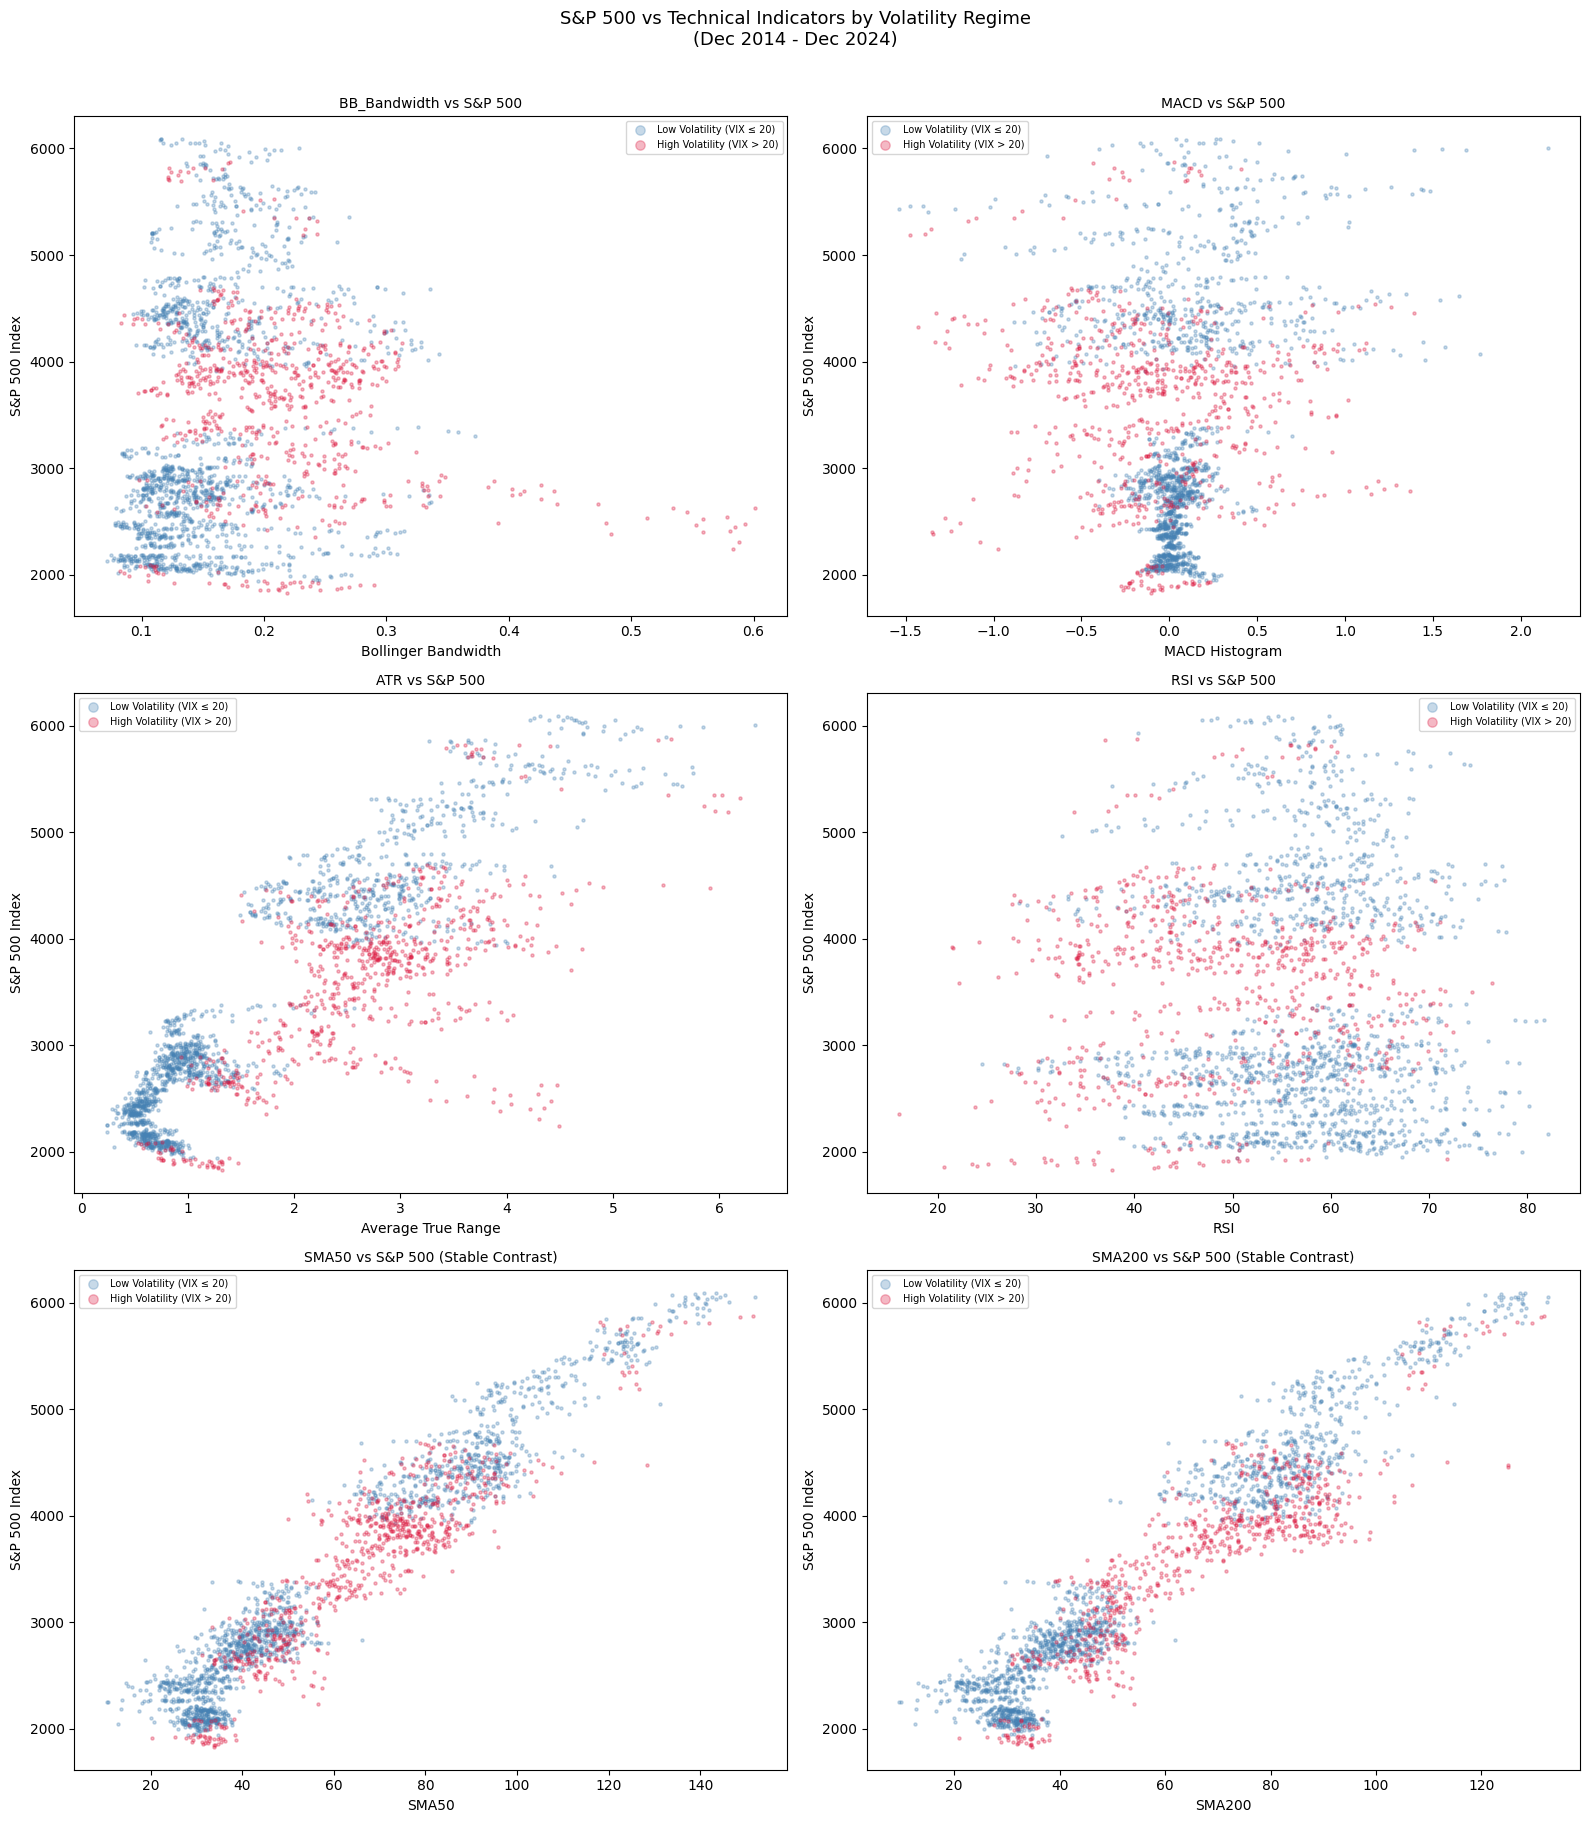

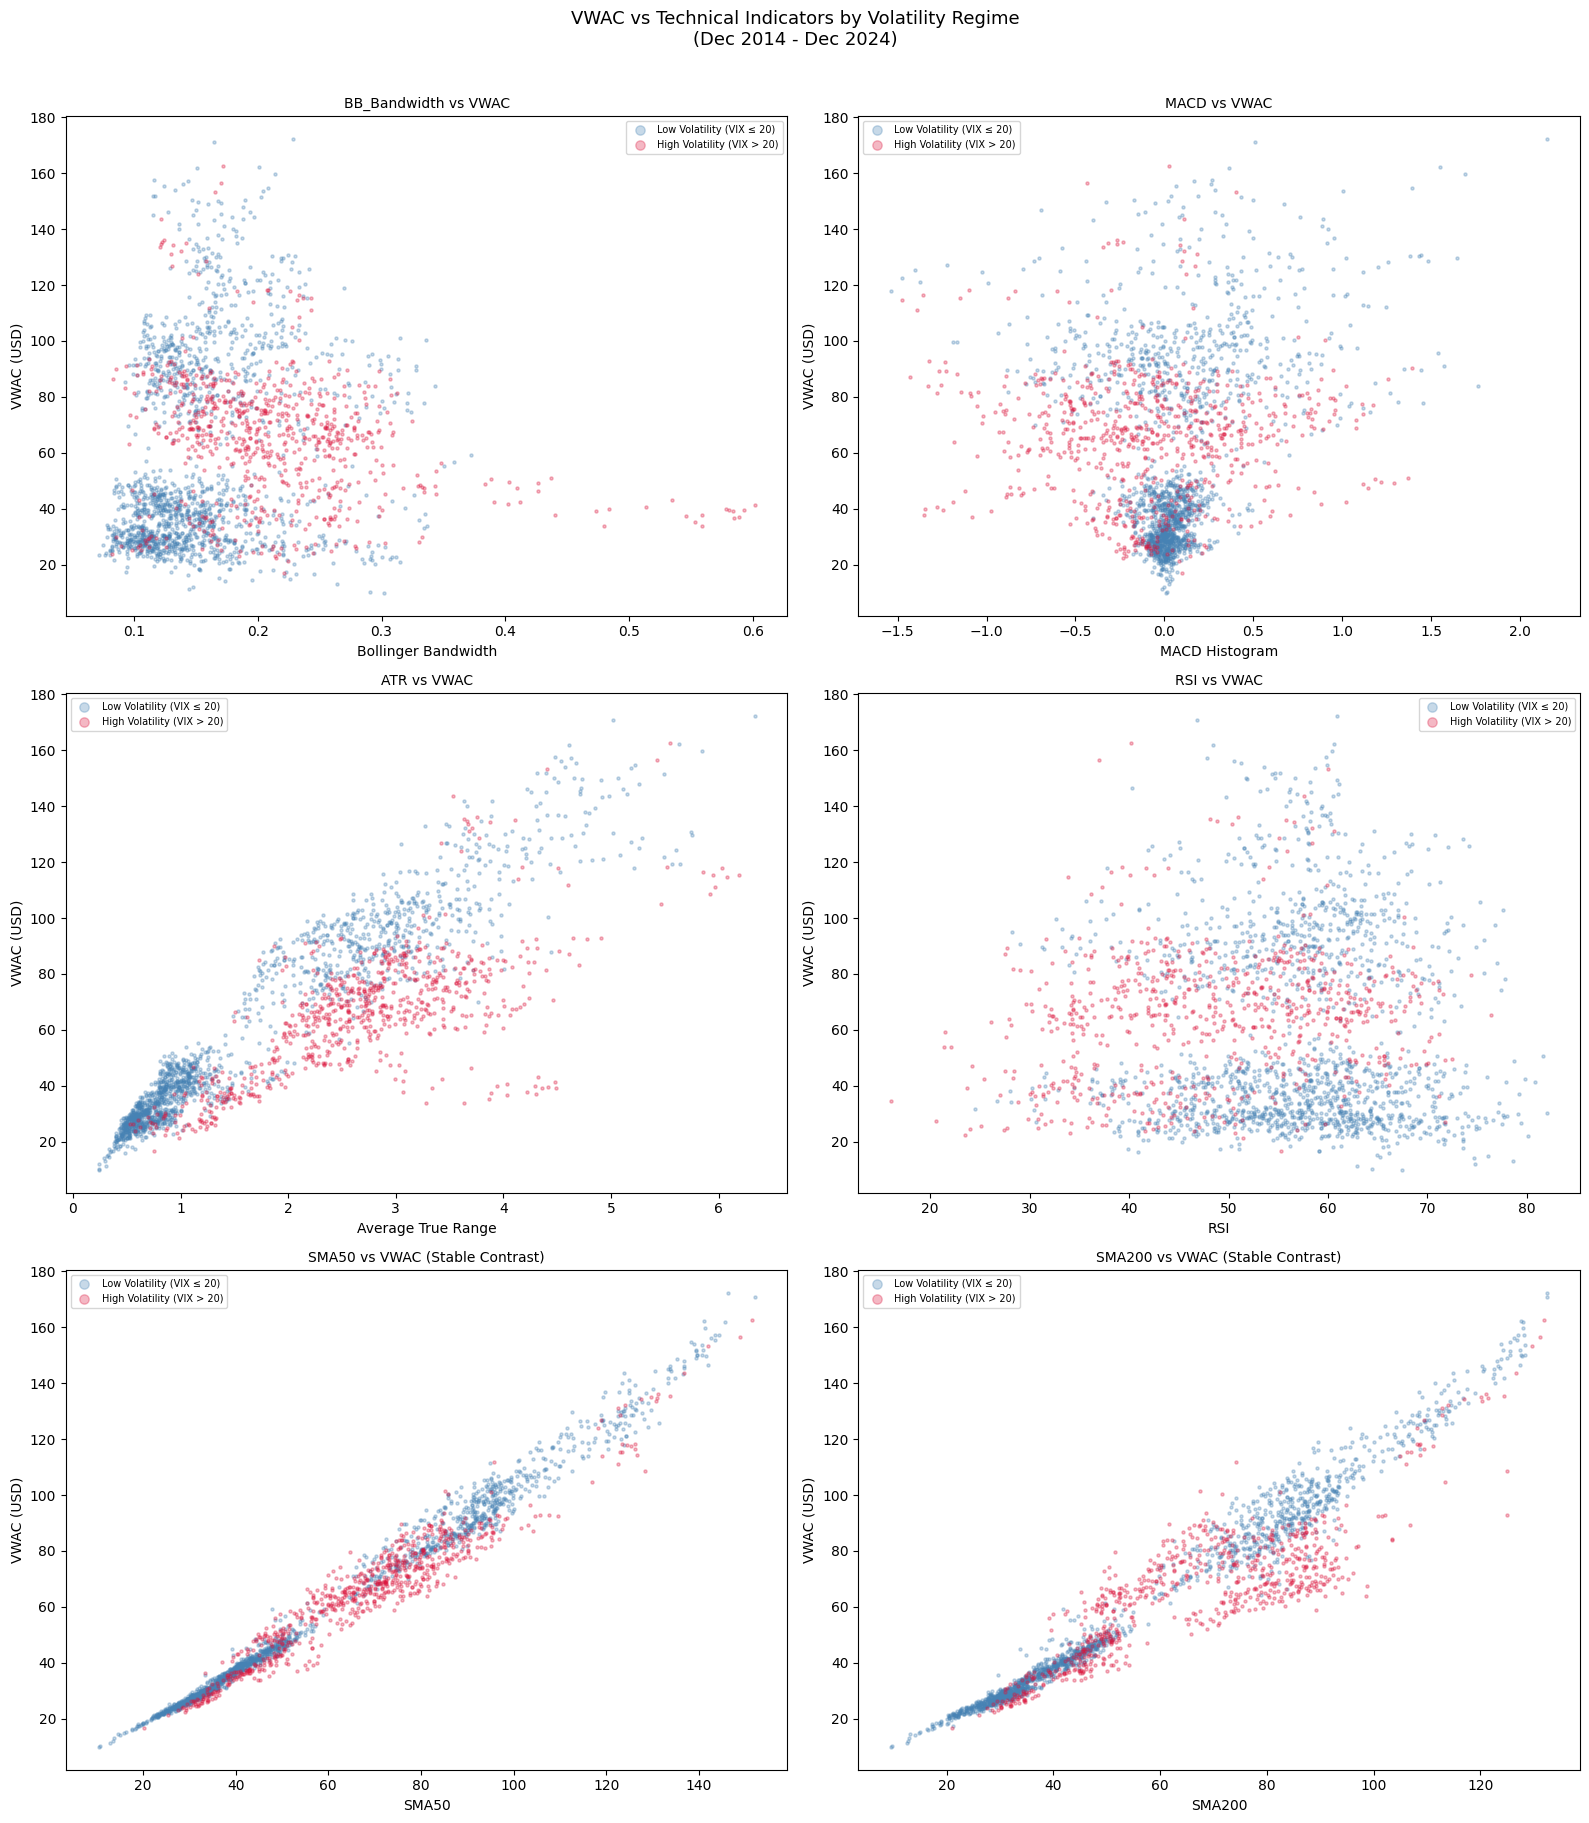

In [14]:
# ─────────────────────────────────────────────
# 13. TECHNICAL INDICATOR SCATTER PLOTS
# ─────────────────────────────────────────────

colors = {0: 'steelblue', 1: 'crimson'}
labels = {0: 'Low Volatility (VIX ≤ 20)', 1: 'High Volatility (VIX > 20)'}

def tech_scatter(ax, x_col, y_col, xlabel, ylabel, title):
    for regime in [0, 1]:
        subset = combined_tech_clean[combined_tech_clean['Volatility'] == regime]
        ax.scatter(subset[x_col], subset[y_col],
                   c=colors[regime],
                   label=labels[regime],
                   alpha=0.3,
                   s=5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7, markerscale=3)

# ── S&P500 Scatter Plots ──
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

tech_scatter(axes[0], 'BB_Bandwidth', 'S&P500',
             'Bollinger Bandwidth', 'S&P 500 Index',
             'BB_Bandwidth vs S&P 500')

tech_scatter(axes[1], 'MACD', 'S&P500',
             'MACD Histogram', 'S&P 500 Index',
             'MACD vs S&P 500')

tech_scatter(axes[2], 'ATR', 'S&P500',
             'Average True Range', 'S&P 500 Index',
             'ATR vs S&P 500')

tech_scatter(axes[3], 'RSI', 'S&P500',
             'RSI', 'S&P 500 Index',
             'RSI vs S&P 500')

tech_scatter(axes[4], 'SMA50', 'S&P500',
             'SMA50', 'S&P 500 Index',
             'SMA50 vs S&P 500 (Stable Contrast)')

tech_scatter(axes[5], 'SMA200', 'S&P500',
             'SMA200', 'S&P 500 Index',
             'SMA200 vs S&P 500 (Stable Contrast)')

plt.suptitle('S&P 500 vs Technical Indicators by Volatility Regime\n(Dec 2014 - Dec 2024)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── VWAC Scatter Plots ──
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

tech_scatter(axes[0], 'BB_Bandwidth', 'VWAC',
             'Bollinger Bandwidth', 'VWAC (USD)',
             'BB_Bandwidth vs VWAC')

tech_scatter(axes[1], 'MACD', 'VWAC',
             'MACD Histogram', 'VWAC (USD)',
             'MACD vs VWAC')

tech_scatter(axes[2], 'ATR', 'VWAC',
             'Average True Range', 'VWAC (USD)',
             'ATR vs VWAC')

tech_scatter(axes[3], 'RSI', 'VWAC',
             'RSI', 'VWAC (USD)',
             'RSI vs VWAC')

tech_scatter(axes[4], 'SMA50', 'VWAC',
             'SMA50', 'VWAC (USD)',
             'SMA50 vs VWAC (Stable Contrast)')

tech_scatter(axes[5], 'SMA200', 'VWAC',
             'SMA200', 'VWAC (USD)',
             'SMA200 vs VWAC (Stable Contrast)')

plt.suptitle('VWAC vs Technical Indicators by Volatility Regime\n(Dec 2014 - Dec 2024)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()